In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import workCon
import os
from eval import get_model_from_run
from tqdm import tqdm
import ipdb
import traceback
import random
import math
import generate_dataset
from scipy.integrate import solve_ivp
import pickle
import plotly.graph_objects as go
from IPython.display import HTML

/home/esmith/.conda/envs/icl_ebonye_pendulum/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mse(theta_model, thetadot_model, theta_rk4, thetadot_rk4):
    """
    Calculates the Mean Squared Error (MSE) between the predicted and true states.

    Args:
        theta_model (np.ndarray or list): Model's predicted theta 
        thetadot_model (np.ndarray or list): Model's predicted thetadot 
        theta_rk4 (np.ndarray or list): True theta using RK4
        thetadot_rk4 (np.ndarray or list): True thetadot using RK4

    Returns:
        float: The computed MSE value, representing the average squared difference between 
        the predicted and true states.
    """
    xs_pred = torch.tensor(np.column_stack((theta_model, thetadot_model)), dtype=torch.float32)
    xs_true = torch.tensor(np.column_stack((theta_rk4, thetadot_rk4)), dtype=torch.float32)
    return (xs_true - xs_pred).pow(2).mean().item()

def load_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    return data


In [3]:
model_run_id = "efc700a2-0b51-4853-885d-557ba3c9d942" #"15bf641c-dbc0-4f2f-b62f-fe04f568aacb"
step = 50000 
numberpend = 100 #200 #5
data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext100_numpends{numberpend}_indistr_alexcode.pkl'
# lambda1s, lambda2s, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# print(f"Loaded data from {data_path}")

In [4]:
def _total_energy(theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    # small helper (matches your conventions)
    c2 = np.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2
    D = np.array([[D11, D12],[D12, D22]])
    dq = np.array([d1, d2])
    KE = 0.5 * dq @ (D @ dq)
    # T1 = 0.5 * I1 * d1**2
    # T2 = 0.5 * (m2 * l1**2 + I2 + 2*m2 * l1 * lc2 * c2) * d1**2 + 0.5 * I2 * d2**2 + (I2 + m2* l1 * lc2 * c2) * d1 * d2
    # KE = T1 + T2

    # U = -m1 * g * lc1 * np.cos(theta1 - np.pi/2.0) - m2 * g * (l1 * np.cos(theta1 - np.pi/2.0) + lc2 * np.cos(theta1 + theta2 - np.pi/2.0))
    # PE = U  # potential energy (up is negative; consistent with physics)

    # potential energy (up is positive; consistent with gym)
    y1 = lc1 * np.cos(theta1 - np.pi/2.0)
    y_tip = l1 * np.cos(theta1 - np.pi/2.0)
    y2 = y_tip + lc2 * np.cos(theta1 + theta2 - np.pi/2.0)
    PE = m1 * 9.81 * y1 + m2 * 9.81 * y2
    # return KE + PE
    return KE, PE


def _total_energy_batch(theta1, theta2, d1, d2,
                  m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    """
    Vectorized total energy for acrobot (PyTorch version).
    
    Parameters:
        theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
        m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
        g : gravity (float)
    
    Returns:
        Total energy (N,) tensor if inputs are batched, else scalar tensor.
    """

    # Convert everything to tensors on the same device/dtype
    device = (theta1.device if isinstance(theta1, torch.Tensor)
              else torch.device("cuda:0"))
    dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
        ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
    )

    # Broadcast to common shape
    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
        theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
    )

    # Kinetic energy
    c2 = torch.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2

    dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
    D = torch.stack([
        torch.stack([D11, D12], dim=-1),
        torch.stack([D12, D22], dim=-1)
    ], dim=-2)  # (N, 2, 2)

    KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

    

    # Potential energy
    y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
    y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
    y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

    PE = m1 * g * y1 + m2 * g * y2

    return KE.cpu().numpy(), PE.cpu().numpy()

In [5]:
# def cost_metric()

def stability_metric(states, K=20):
    """
    Computes the stability metric for a given set of states.

    Args:
        states (np.ndarray): Array of shape (T, state_dim) representing the states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        float: The computed stability metric, representing the average deviation from goal state of last K steps.
    """
    if states.shape[0] < K + 1:
        raise ValueError("The number of time steps in states must be greater than K.")
    
    # Extract the last K states
    final_states = states[-K:]

    # convert angles to cosine and sine
    final_states = final_states.cpu().numpy() if torch.is_tensor(final_states) else final_states
    xs_cos1 = np.cos(final_states[:, 0])
    xs_sin1 = np.sin(final_states[:, 0])
    xs_cos2 = np.cos(final_states[:, 1])
    xs_sin2 = np.sin(final_states[:, 1])
    xs1dot = final_states[:, 2]
    xs2dot = final_states[:, 3]
    final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]

    # Compute the Euclidean distance from the goal state for each of the last K states
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
    return np.mean(distances)

def stability_metric_batch(states_batch, K=20):
    """
    Computes the stability metric for a batch of states.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        np.ndarray: Array of shape (N,) containing the stability metric for each sequence.
    """
    if isinstance(states_batch, torch.Tensor):
        states_batch = states_batch.cpu().numpy()
    
    final_states = states_batch[:, -K:, :]
    xs_cos1 = np.cos(final_states[:, :, 0])
    xs_sin1 = np.sin(final_states[:, :, 0])
    xs_cos2 = np.cos(final_states[:, :, 1])
    xs_sin2 = np.sin(final_states[:, :, 1])
    xs1dot = final_states[:, :, 2]
    xs2dot = final_states[:, :, 3]
    final_states_transformed = np.stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot), axis=-1)

    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=-1)
    return np.mean(distances, axis=1)

def swinging_metric_batch(control_labels):
    """
    Computes the swinging metric for a batch of control labels.

    Args:
        control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
    Returns:
        np.ndarray: Array of shape (N,) containing the swinging metric for each sequence.
    """
    if isinstance(control_labels, torch.Tensor):
        control_labels = control_labels.cpu().numpy()
    
    # Compute the sum of time steps where controller is in swing-up mode (control label == 0)
    mask = (control_labels == 0)
    swinging_durations = np.sum(mask, axis=1)
    return swinging_durations

def swinging_difference_batch(true_control_labels, predicted_control_labels):
    """
    Compares swinging of true controller versus predicted control sequence.

    Args:
        true_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of true control inputs over time.
        predicted_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of predicted control inputs over time.

    """
    if isinstance(true_control_labels, torch.Tensor):
        true_control_labels = true_control_labels.cpu().numpy()
    if isinstance(predicted_control_labels, torch.Tensor):
        predicted_control_labels = predicted_control_labels.cpu().numpy()

    # Compute the difference in swinging durations
    true_swinging = swinging_metric_batch(true_control_labels)
    predicted_swinging = swinging_metric_batch(predicted_control_labels)
    return np.abs(true_swinging - predicted_swinging)

def stability_fraction_batch(predicted_states, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps.
    Args:
        predicted_states (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable.
    """
    if isinstance(predicted_states, torch.Tensor):
        predicted_states = predicted_states.cpu().numpy()
    
    N = predicted_states.shape[0]
    stable_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        final_states = predicted_states[i, -K:, :]
        xs_cos1 = np.cos(final_states[:, 0])
        xs_sin1 = np.sin(final_states[:, 0])
        xs_cos2 = np.cos(final_states[:, 1])
        xs_sin2 = np.sin(final_states[:, 1])
        xs1dot = final_states[:, 2]
        xs2dot = final_states[:, 3]
        final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
        # distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
        # import pdb; pdb.set_trace()
        # if np.all(distances < threshold):
        if np.all(np.abs(np.sin(final_states[:,0])) < 0.2) and np.all(np.abs(np.sin(final_states[:,1])) < 0.3):
            stable_count += 1
    return stable_count / N

def stability_fraction_batch_window(predicted_states, K=20, threshold_sin1=0.2, threshold_sin2=0.3):
    """
    Computes the fraction of systems that stabilized for at least K consecutive steps 
    at any point during the trajectory.
    """
    if isinstance(predicted_states, torch.Tensor):
        predicted_states = predicted_states.cpu().numpy()
    
    N, T, _ = predicted_states.shape
    stable_count = 0
    
    # 1. Pre-calculate the boolean stability mask for the entire batch
    # We only care about the sin of the first two state variables
    sin_theta1 = np.abs(np.sin(predicted_states[:, :, 0]))
    sin_theta2 = np.abs(np.sin(predicted_states[:, :, 1]))
    
    # Boolean array of shape (N, T): True if state at time t is "near" equilibrium
    is_at_equilibrium = (sin_theta1 < threshold_sin1) & (sin_theta2 < threshold_sin2)
    
    for i in range(N):
        # 2. Find the longest contiguous block of True values
        # We use a trick: diff() finds where the state changes from stable to unstable
        row = is_at_equilibrium[i]
        
        # Count consecutive True values
        # This approach is efficient for finding if ANY window of size K exists
        count = 0
        max_consecutive = 0
        for val in row:
            if val:
                count += 1
                if count >= K:
                    max_consecutive = count
                    break # Optimization: we found a window, no need to keep looking
            else:
                count = 0
        
        if max_consecutive >= K:
            stable_count += 1
            
    return stable_count / N

def stability_fraction_all_contexts_batch(predicted_states_dict, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps for all attempts.
    Args:
        predicted_states_dict (dict): Dictionary where keys are context identifiers and values are arrays of shape (N, T, state_dim) representing N sequences of states over time for that context.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable in at least one context.
    """
    contexts = list(predicted_states_dict.keys())
    N = predicted_states_dict[contexts[0]].shape[0]
    stable_count = 0
    total_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        is_stable = False
        for context in contexts:
            predicted_states = predicted_states_dict[context].cpu().numpy() if torch.is_tensor(predicted_states_dict[context]) else predicted_states_dict[context]
            final_states = predicted_states[i, -K:, :]
            xs_cos1 = np.cos(final_states[:, 0])
            xs_sin1 = np.sin(final_states[:, 0])
            xs_cos2 = np.cos(final_states[:, 1])
            xs_sin2 = np.sin(final_states[:, 1])
            xs1dot = final_states[:, 2]
            xs2dot = final_states[:, 3]
            final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
            distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
            # if np.all(distances < threshold):
            if np.all(np.abs(np.sin(final_states[:,0])) < 0.2) and np.all(np.abs(np.sin(final_states[:,1])) < 0.3):
                # is_stable = True
                # break
                stable_count += 1
            total_count += 1
        # if is_stable:
            # stable_count += 1
    # return stable_count / N
    print(f"Stable count: {stable_count}, Total count: {total_count}")
    return stable_count / total_count




def energy_metric_batch(true_states_batch, predicted_states_batch, link_lengths1, link_lengths2, link_masses1, link_masses2):
    """
    Computes the difference in total energy for true vs predicted trajectories.
    Args:
        true_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of true states over time.
        predicted_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of predicted states over time.
        link_lengths1 (float or np.ndarray): Length(s) of the first link(s).
        link_lengths2 (float or np.ndarray): Length(s) of the second link(s).
        link_masses1 (float or np.ndarray): Mass(es) of the first link(s).
        link_masses2 (float or np.ndarray): Mass(es) of the second link(s).
    Returns:
        np.ndarray: Array of shape (N,) containing the average energy difference for each sequence.
    """
    if isinstance(true_states_batch, torch.Tensor):
        true_states_batch = true_states_batch.cpu().numpy()
    if isinstance(predicted_states_batch, torch.Tensor):
        predicted_states_batch = predicted_states_batch.cpu().numpy()
    
    theta1_true = true_states_batch[:, :, 0]
    theta2_true = true_states_batch[:, :, 1]
    d1_true = true_states_batch[:, :, 2]
    d2_true = true_states_batch[:, :, 3]

    theta1_pred = predicted_states_batch[:, :, 0]
    theta2_pred = predicted_states_batch[:, :, 1]
    d1_pred = predicted_states_batch[:, :, 2]
    d2_pred = predicted_states_batch[:, :, 3]

    # KE_true, PE_true = _total_energy_batch(theta1_true, theta2_true, d1_true, d2_true,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)
    # KE_pred, PE_pred = _total_energy_batch(theta1_pred, theta2_pred, d1_pred, d2_pred,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)

    for i in range(true_states_batch.shape[1]):
        KE_true, PE_true = _total_energy_batch(theta1_true[:, i], theta2_true[:, i], d1_true[:, i], d2_true[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        KE_pred, PE_pred = _total_energy_batch(theta1_pred[:, i], theta2_pred[:, i], d1_pred[:, i], d2_pred[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        if i == 0:
            KE_true_all = KE_true[:, None]
            PE_true_all = PE_true[:, None]
            KE_pred_all = KE_pred[:, None]
            PE_pred_all = PE_pred[:, None]
        else:
            KE_true_all = np.concatenate((KE_true_all, KE_true[:, None]), axis=1)
            PE_true_all = np.concatenate((PE_true_all, PE_true[:, None]), axis=1)
            KE_pred_all = np.concatenate((KE_pred_all, KE_pred[:, None]), axis=1)
            PE_pred_all = np.concatenate((PE_pred_all, PE_pred[:, None]), axis=1)

    # total_energy_true = KE_true + PE_true
    # total_energy_pred = KE_pred + PE_pred

    # energy_diff = np.abs(total_energy_true - total_energy_pred)
    total_energy_true = KE_true_all + PE_true_all
    total_energy_pred = KE_pred_all + PE_pred_all
    energy_diff = np.abs(total_energy_true - total_energy_pred)
    # import pdb; pdb.set_trace()
    ## do l2 instead of l1
    
    return np.mean(energy_diff, axis=1)

def evaluate_metrics(states_batch, control_labels_batch, K=20):
    """
    Evaluates both stability and swinging metrics for a batch of states and control labels.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        control_labels_batch (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        tuple: Two np.ndarrays of shape (N,) containing the stability and swinging metrics for each sequence.
    """
    stability_metrics = stability_metric_batch(states_batch, K)
    swinging_metrics = swinging_metric_batch(control_labels_batch)
    return stability_metrics, swinging_metrics
    

  0%|          | 0/7 [00:00<?, ?it/s]

Evaluating metrics for context length: 1


 14%|█▍        | 1/7 [00:01<00:11,  1.98s/it]

Evaluating metrics for context length: 5


 29%|██▊       | 2/7 [00:03<00:07,  1.42s/it]

...

 71%|███████▏  | 5/7 [00:05<00:02,  1.06s/it]

Evaluating metrics for context length: 75


 86%|████████▌ | 6/7 [00:06<00:01,  1.00s/it]

Evaluating metrics for context length: 100


100%|██████████| 7/7 [00:07<00:00,  1.11s/it]


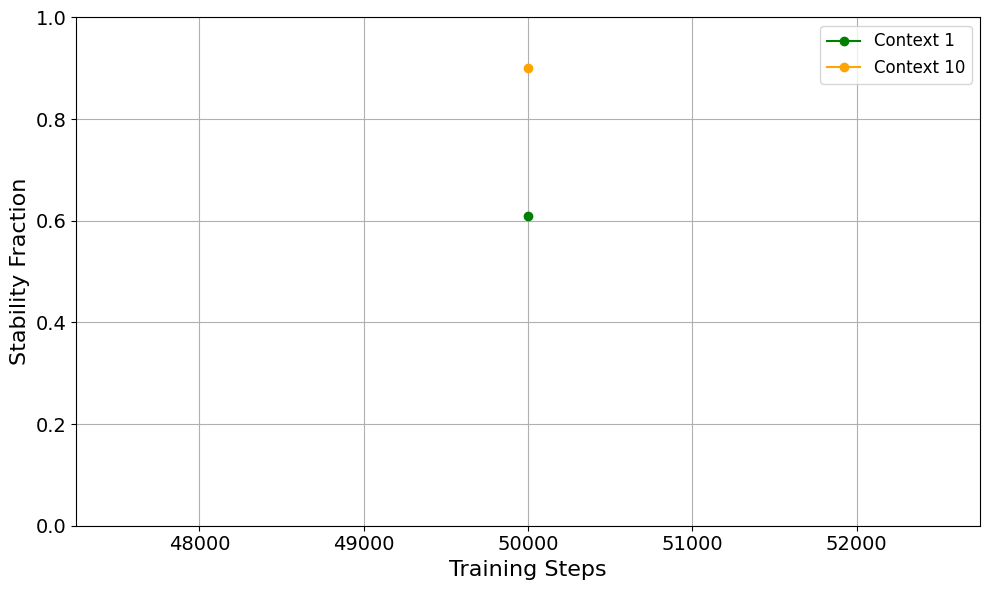

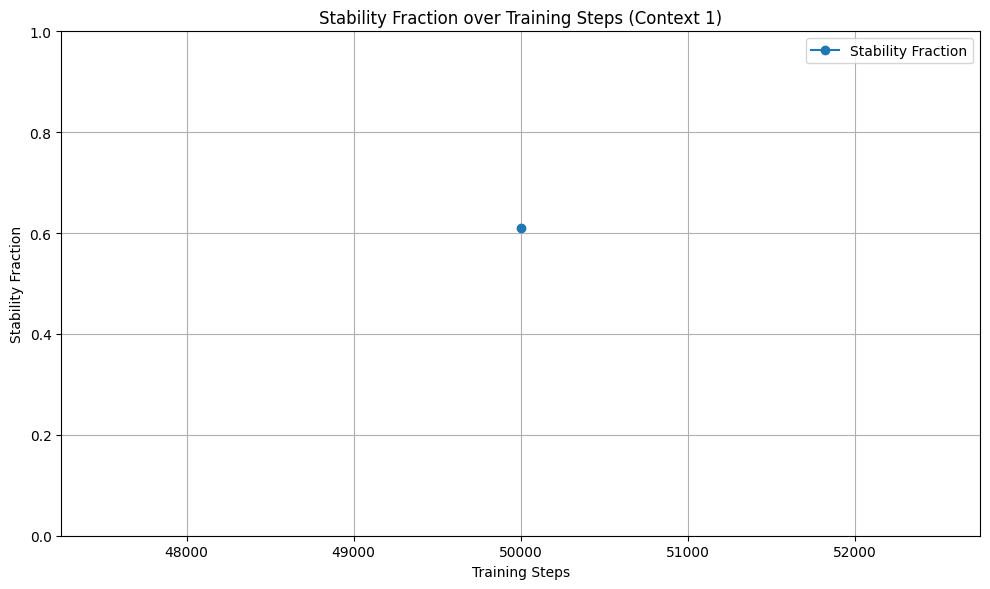

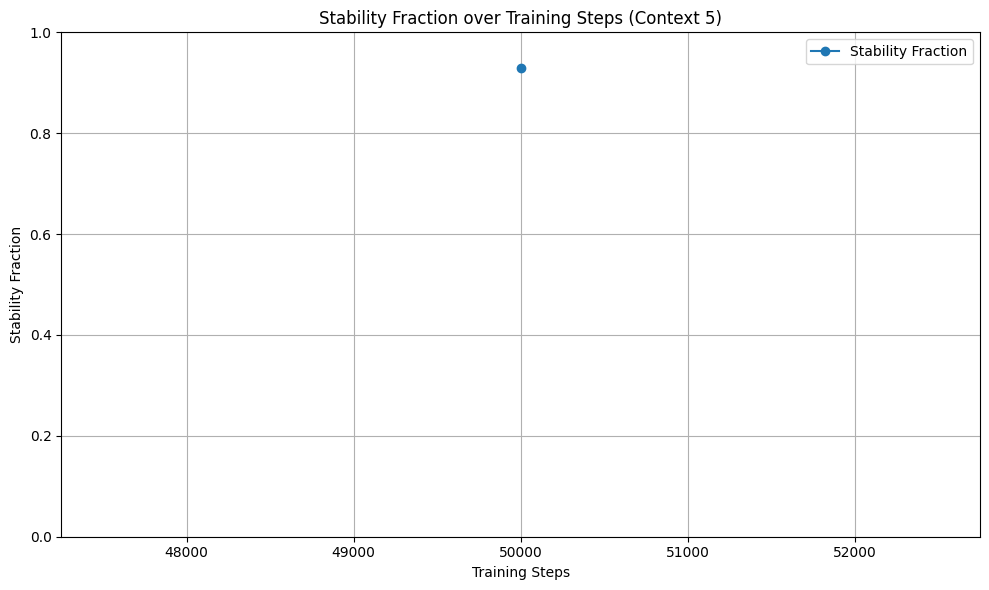

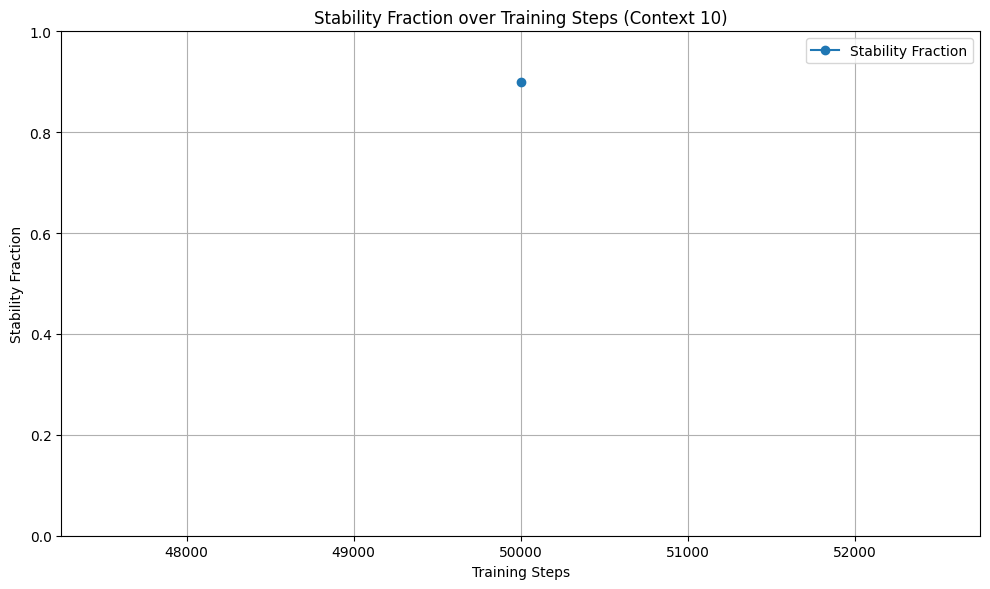

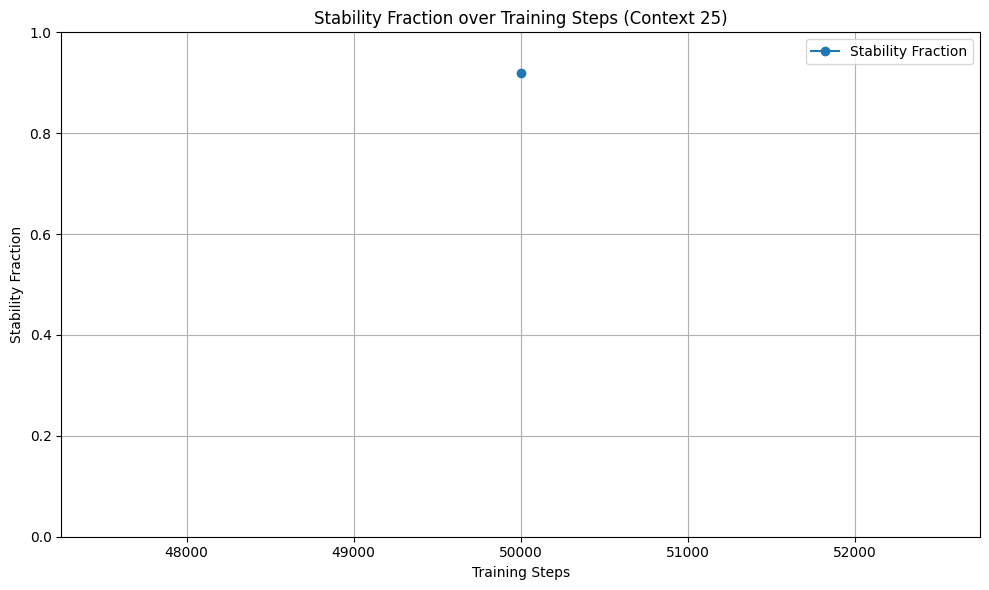

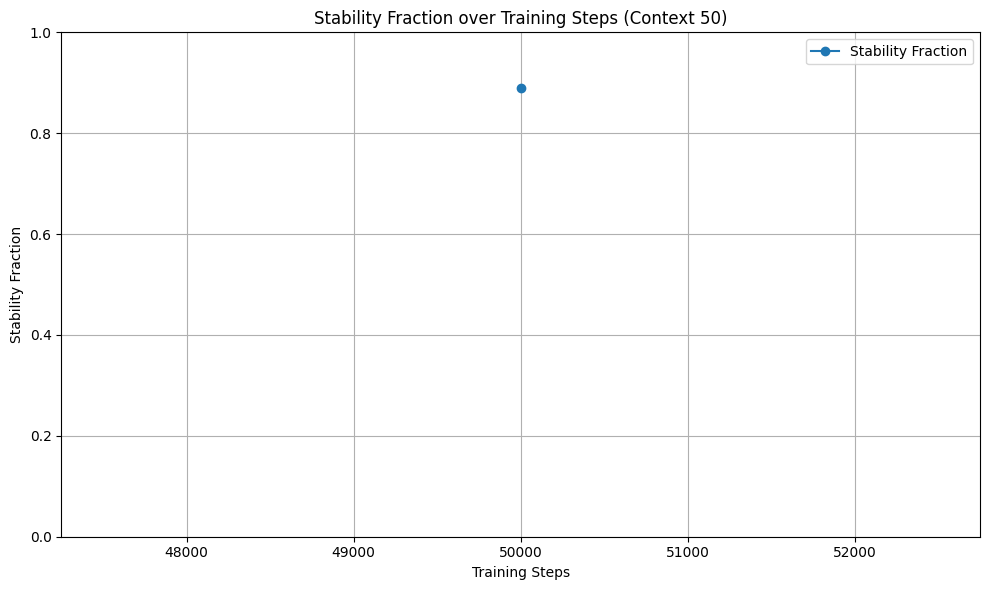

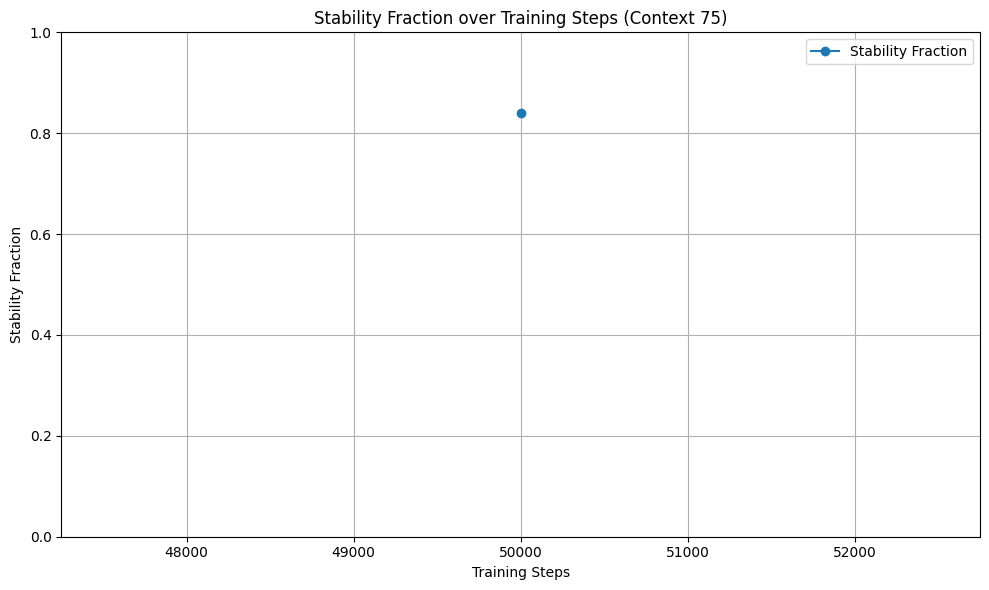

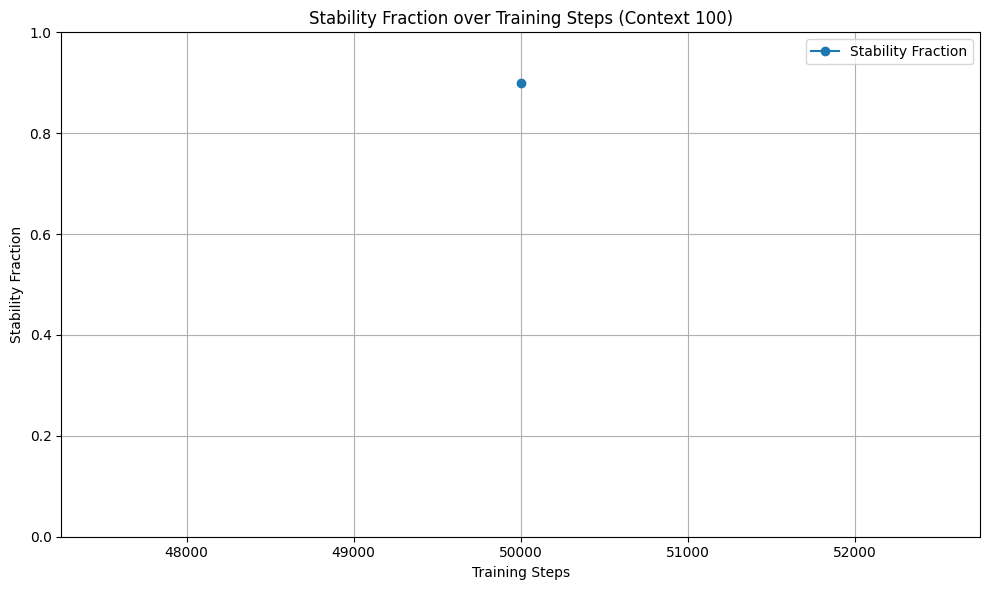

In [6]:
# steps_list = [50000, 75000, 100000, 125000, 145000, 185000, 200000, 230000, 235000, 240000, 245000]
# steps_list = [125000]
# steps_list = [5000, 10000, 15000, 20000, 25000, 30000, 40000, 50000, 60000, 75000, 100000, 125000, 
            #   145000, 165000, 185000, 200000, 230000, 235000, 240000, 245000, 250000, 255000, 260000, 275000, 284408]
# context_lengths = [1, 10, 20, 30, 40, 50]
steps_list = [50000]
contexts = [1, 5, 10, 25, 50, 75, 100]
# context_lengths = [20]
mode = "indistr" # "indistr" or "ood"

results = {}
metrics = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics:
    results[metric] = {}

# # create prediction dictionary
# predicted_states_dict = {step: {} for step in steps_list}
# for step in steps_list:
#     data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
#     link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#     print(f"Loaded data from {data_path}")
#     for context in context_lengths:
#         pred_traj = torch.stack(phase_data[context])
#         predicted_states_dict[step][context] = pred_traj

# print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
# print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")


# just context 30 for now
# context = 50
# fig_select, ax_select = plt.subplots(2, 2, figsize=(12, 9))
# ax_select = ax_select.flatten()
fig_select, ax_select = plt.subplots(figsize=(10, 6))
colors = ['green', 'orange', 'purple', 'brown']
select_contexts = [1, 10, 30, 40]
from tqdm import tqdm
for context in tqdm(contexts):
    print(f"Evaluating metrics for context length: {context}")
    for step in steps_list:
        data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext100_numpends{numberpend}_{mode}_alexcode.pkl'
        link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
        # print(f"Loaded data from {data_path}")

        pred_traj = torch.stack(phase_data[context])
        
        stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[context])[:,:,-1], K=100)
        
        ground_truth_data_controls = data_and_controls[0]
        ground_truth_control_labels = [ground_truth_data_controls[i][1][:,1][:-1] for i in range(len(ground_truth_data_controls))]
        true_traj = [ground_truth_data_controls[i][0] for i in range(len(ground_truth_data_controls))]
        true_traj = np.stack(true_traj)
        # import pdb; pdb.set_trace()
        # energy_metric = energy_metric_batch(torch.tensor(true_traj), pred_traj, np.stack(link_lengths1), np.stack(link_lengths2), np.stack(link_masses1), np.stack(link_masses2))
        # import pdb; pdb.set_trace()
        # swinging_compare_metrics = swinging_difference_batch(np.stack(ground_truth_control_labels), torch.stack(controls_data[context])[:,:,-1])

        # stability_fraction = stability_fraction_batch(pred_traj, K=10, threshold=0.3)
        stability_fraction = stability_fraction_batch_window(pred_traj, K=20, threshold_sin1=0.2, threshold_sin2=0.3)
        # plot trajs for debugging
        # plt.figure()
        # count = 0
        # for i in range(pred_traj.shape[0]):
        #     if np.all(np.abs(np.sin(pred_traj[i,-10:,0].cpu().numpy())) < 0.2) and np.all(np.abs(np.sin(pred_traj[i,-10:,1].cpu().numpy())) < 0.3):
        #         count += 1
        #         plt.plot(np.sin(pred_traj[i,:,0].cpu().numpy()), label=f'Pred {i}', alpha=0.5, color='blue')
        #     else:
        #         plt.plot(np.sin(pred_traj[i,:,0].cpu().numpy()), label=f'Pred {i}', alpha=0.5, color='red')
            
        # print(f"Number of stable trajectories (context {context}, step {step}): {count} out of {pred_traj.shape[0]}")
        # plt.title(f'Step {step} Predicted Trajectories (Context {context})')
        # plt.show()

        # import pdb; pdb.set_trace()

        median_stability = np.median(stability_metrics)
        mean_stability = np.mean(stability_metrics)
        twentyfifth_percentile = np.percentile(stability_metrics, 25)
        seventyfifth_percentile = np.percentile(stability_metrics, 75)

        median_swinging = np.median(swinging_metrics)
        mean_swinging = np.mean(swinging_metrics)
        twentyfifth_swinging = np.percentile(swinging_metrics, 25)
        seventyfifth_swinging = np.percentile(swinging_metrics, 75)

        # median_energy = np.median(energy_metric)
        # mean_energy = np.mean(energy_metric)
        # twentyfifth_energy = np.percentile(energy_metric, 25)
        # seventyfifth_energy = np.percentile(energy_metric, 75)

        results['stability'][step] = {
            'median': median_stability,
            '25th_percentile': twentyfifth_percentile,
            '75th_percentile': seventyfifth_percentile,
            'mean': mean_stability
        }

        results['swinging'][step] = {
            'median': median_swinging,
            '25th_percentile': twentyfifth_swinging,
            '75th_percentile': seventyfifth_swinging,
            'mean': mean_swinging

        }

        # results['energy'][step] = {
        #     'median': median_energy,
        #     '25th_percentile': twentyfifth_energy,
        #     '75th_percentile': seventyfifth_energy,
        #     'mean': mean_energy
        # }
        results['stability_fraction'][step] = stability_fraction

        # results['swinging_compare'][step] = {
        #     'median': np.median(swinging_compare_metrics),
        #     '25th_percentile': np.percentile(swinging_compare_metrics, 25),
        #     '75th_percentile': np.percentile(swinging_compare_metrics, 75),
        #     'mean': np.mean(swinging_compare_metrics)
        # }

    # visulaize results
    import matplotlib.pyplot as plt
    import pandas as pd

    # prepare data for plotting

    data = []


    for step in steps_list:
        for metric in metrics:
            # print(f"step: {step}, metric: {metric}")
            if metric == 'stability_fraction':
                data.append({
                    'metric': metric,
                    'step': step,
                    'value': results[metric][step]
                })
            else:
                # data.append({
                #     'metric': metric,
                #     'step': step,
                #     'median': results[metric][step]['median'],
                #     'percentile_25': results[metric][step]['25th_percentile'],
                #     'percentile_75': results[metric][step]['75th_percentile'],
                #     'mean': results[metric][step]['mean']

                # })
                pass

    # visualize results
    # fig1, ax1 = plt.subplots(figsize=(10, 6))
    # fig2, ax2 = plt.subplots(figsize=(10, 6))
    # fig3, ax3 = plt.subplots(figsize=(10, 6))
    # fig4, ax4 = plt.subplots(figsize=(10, 6))
    df = pd.DataFrame(data)
    df = df.sort_values(by='step')

    # for metric, ax in zip(metrics, [ax1, ax2, ax3, ax4]):
    #     metric_data = df[df['metric'] == metric]
    #     if metric == 'stability_fraction':
    #         ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
    #         ax.set_title(f'Stability Fraction over Training Steps')
    #         ax.set_xlabel('Training Steps')
    #         ax.set_ylabel('Stability Fraction')
    #         ax.set_ylim(0, 1)
    #         ax.legend()
    #         ax.grid(True)
    #         plt.tight_layout()
    #         continue
    #     else:
    #         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
    #         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
    #         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
    #         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
    #         # ax.set_xlabel('Training Steps')
    #         # ax.set_ylabel(f'{metric.capitalize()} Metric')
    #         # ax.legend()
    #         # ax.grid(True)
    #         # plt.tight_layout()
    #         pass
    # plt.show()

    # create plot with subplots for each metric to save
    # fig_all, ax_all = plt.subplots(1, 4, figsize=(18, 4))
    # fig_all, ax_all = plt.subplots(1, 1, figsize=(20, 5))
    fig = plt.figure(figsize=(10, 6))
    # for metric, ax in zip(metrics, ax_all):
    for metric in metrics:
        metric_data = df[df['metric'] == metric]
        if metric == 'stability_fraction':
            # ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
            # ax.set_title(f'Stability Fraction over Training Steps')
            # ax.set_xlabel('Training Steps')
            # ax.set_ylabel('Stability Fraction')
            # ax.set_ylim(0, 1)
            # ax.legend()
            # ax.grid(True)
            # plt.tight_layout()
            plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
            plt.title(f'Stability Fraction over Training Steps (Context {context})')
            plt.xlabel('Training Steps')
            plt.ylabel('Stability Fraction')
            plt.ylim(0, 1)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()

            if context in select_contexts:
                # ax_select[select_contexts.index(context)].plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
                ax_select.plot(metric_data['step'], metric_data['value'], label=f'Context {context}', marker='o', color=colors[select_contexts.index(context)])
                # ax_select[select_contexts.index(context)].set_title(f'Stability Fraction vs Training Steps (Context {context})')
                # ax_select[select_contexts.index(context)].set_xlabel('Training Steps')
                # ax_select[select_contexts.index(context)].set_ylabel('Stability Fraction')
                # ax_select[select_contexts.index(context)].set_ylim(0, 1)
                # ax_select[select_contexts.index(context)].legend()
                # ax_select[select_contexts.index(context)].grid(True)
                ax_select.set_xlabel('Training Steps', fontsize=16)
                ax_select.set_ylabel('Stability Fraction', fontsize=16)
                ax_select.set_ylim(0, 1)
                ax_select.tick_params(axis='x', labelsize=14)
                ax_select.tick_params(axis='y', labelsize=14)
                ax_select.legend(fontsize=12)
                ax_select.grid(True)
                plt.tight_layout()


            continue
        else:
            # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
            # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
            # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
            # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
            # ax.set_xlabel('Training Steps')
            # ax.set_ylabel(f'{metric.capitalize()} Metric')
            # ax.legend()
            # ax.grid(True)
            pass
    plt.tight_layout()
    # plt.show()

    # fig_select.suptitle('Acrobot: Stability Fraction vs Training Step for Select Context Lengths')
    # fig_select.tight_layout(rect=[0, 0, 1, 0.95])
    fig_select.tight_layout()
    output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems_mode{mode}'
    # os.makedirs(output_dir, exist_ok=True)

    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.png'))
    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')
    # plt.close(fig_select)
    

    ### sanity check, for systems that stabilized, see if considerable amt of time spend in lqr mode
    ### null model: see how ground truth controller performs if small noise is added to swingup as well as lqr (fair model to compare gpt to)

    # create folder and save subplots
    # output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
    # os.makedirs(output_dir, exist_ok=True)
    # folder = f"context{context}_100systems"
    # os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
    # fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems_mode{mode}.png'))
    # fig.savefig(os.path.join(output_dir, f'stability_fraction_context{context}_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')



            





In [7]:
# # visulaize results
# import matplotlib.pyplot as plt
# import pandas as pd

# # prepare data for plotting

# data = []


# for step in steps_list:
#     for metric in metrics:
#         # print(f"step: {step}, metric: {metric}")
#         if metric == 'stability_fraction':
#             data.append({
#                 'metric': metric,
#                 'step': step,
#                 'value': results[metric][step]
#             })
#         else:
#             # data.append({
#             #     'metric': metric,
#             #     'step': step,
#             #     'median': results[metric][step]['median'],
#             #     'percentile_25': results[metric][step]['25th_percentile'],
#             #     'percentile_75': results[metric][step]['75th_percentile'],
#             #     'mean': results[metric][step]['mean']

#             # })
#             pass

# # visualize results
# fig1, ax1 = plt.subplots(figsize=(10, 6))
# fig2, ax2 = plt.subplots(figsize=(10, 6))
# fig3, ax3 = plt.subplots(figsize=(10, 6))
# fig4, ax4 = plt.subplots(figsize=(10, 6))
# df = pd.DataFrame(data)
# df = df.sort_values(by='step')

# for metric, ax in zip(metrics, [ax1, ax2, ax3, ax4]):
#     metric_data = df[df['metric'] == metric]
#     if metric == 'stability_fraction':
#         ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         ax.set_title(f'Stability Fraction over Training Steps')
#         ax.set_xlabel('Training Steps')
#         ax.set_ylabel('Stability Fraction')
#         ax.set_ylim(0, 1)
#         ax.legend()
#         ax.grid(True)
#         plt.tight_layout()
#         continue
#     else:
#         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
#         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
#         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
#         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel(f'{metric.capitalize()} Metric')
#         # ax.legend()
#         # ax.grid(True)
#         # plt.tight_layout()
#         pass
# plt.show()

# # create plot with subplots for each metric to save
# # fig_all, ax_all = plt.subplots(1, 4, figsize=(18, 4))
# # fig_all, ax_all = plt.subplots(1, 1, figsize=(20, 5))
# fig = plt.figure(figsize=(10, 6))
# # for metric, ax in zip(metrics, ax_all):
# for metric in metrics:
#     metric_data = df[df['metric'] == metric]
#     if metric == 'stability_fraction':
#         # ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         # ax.set_title(f'Stability Fraction over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel('Stability Fraction')
#         # ax.set_ylim(0, 1)
#         # ax.legend()
#         # ax.grid(True)
#         # plt.tight_layout()
#         plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         plt.title(f'Stability Fraction over Training Steps (Context {context})')
#         plt.xlabel('Training Steps')
#         plt.ylabel('Stability Fraction')
#         plt.ylim(0, 1)
#         plt.legend()
#         plt.grid(True)
#         plt.tight_layout()
#         continue
#     else:
#         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
#         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
#         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
#         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel(f'{metric.capitalize()} Metric')
#         # ax.legend()
#         # ax.grid(True)
#         pass
# plt.tight_layout()
# plt.show()

# ### sanity check, for systems that stabilized, see if considerable amt of time spend in lqr mode
# ### null model: see how ground truth controller performs if small noise is added to swingup as well as lqr (fair model to compare gpt to)

# # create folder and save subplots
# output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
# os.makedirs(output_dir, exist_ok=True)
# # folder = f"context{context}_100systems"
# # os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
# fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems.png'))



In [8]:
# # create prediction dictionary
# predicted_states_dict = {step: {} for step in steps_list}
# for step in steps_list:
#     data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
#     link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#     # print(f"Loaded data from {data_path}")
#     for context in context_lengths:
#         pred_traj = torch.stack(phase_data[context])
#         predicted_states_dict[step][context] = pred_traj

# print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
# print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")

# fracs = {}
# for step in steps_list:
#     # for context in context_lengths:
#     stability_fraction_all_contexts = stability_fraction_all_contexts_batch(predicted_states_dict[step], K=20, threshold=0.3)
#     fracs[step] = stability_fraction_all_contexts
#     print(f"Step: {step}, Stability Fraction (any context): {stability_fraction_all_contexts}")

In [9]:
# # Plot and save results
# fig_all_contexts = plt.figure(figsize=(10, 6))
# plt.plot(list(fracs.keys()), list(fracs.values()), marker='o')
# plt.title('Stability Fraction (any context) over Training Steps')
# plt.xlabel('Training Steps')
# plt.ylabel('Stability Fraction (any context)')
# plt.ylim(0, 1)
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# fig_all_contexts.savefig(os.path.join(output_dir, f'stability_fraction_any_context_100systems.png'))

In [10]:
# steps_list2 = [230000]
# context_lengths = [1, 10, 20, 30, 40, 50]

steps_list2 = [300000] #50000] #, 60000, 100000, 135000, 300000]
numberpend = 100
contexts2 = [1, 5, 10, 25, 50] #, 75] #, 100]
# mode = "ood" # "indistr" or "ood"
modes = ["indistr","ood"]

results2 = {}
metrics2 = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics2:
    results2[metric] = {}


# for step in steps_list2:
for step in tqdm(steps_list2, desc="Steps2"):
    # for ctx in context_lengths:
    for ctx in contexts2:
        for mode in modes:
            data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext100_numpends{numberpend}_{mode}_alexcode.pkl'
            link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
            print(f"Loaded data from {data_path}")

            pred_traj = torch.stack(phase_data[ctx])
            
            stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[ctx])[:,:,-1], K=100)

            # stability_fraction = stability_fraction_batch(pred_traj, K=10, threshold=0.3)
            stability_fraction = stability_fraction_batch_window(pred_traj, K=150, threshold_sin1=0.2, threshold_sin2=0.3)
            
            median_stability = np.median(stability_metrics)
            mean_stability = np.mean(stability_metrics)
            twentyfifth_percentile = np.percentile(stability_metrics, 25)
            seventyfifth_percentile = np.percentile(stability_metrics, 75)

            median_swinging = np.median(swinging_metrics)
            mean_swinging = np.mean(swinging_metrics)
            twentyfifth_swinging = np.percentile(swinging_metrics, 25)
            seventyfifth_swinging = np.percentile(swinging_metrics, 75)

            # results2['stability'][(step, ctx)] = {
            #     'median': median_stability,
            #     '25th_percentile': twentyfifth_percentile,
            #     '75th_percentile': seventyfifth_percentile,
            #     'mean': mean_stability
            # }

            # results2['swinging'][(step, ctx)] = {
            #     'median': median_swinging,
            #     '25th_percentile': twentyfifth_swinging,
            #     '75th_percentile': seventyfifth_swinging,
            #     'mean': mean_swinging
            # }
            results2['stability_fraction'][(step, ctx, mode)] = stability_fraction



Steps2:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_ood_alexcode.pkl
Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_indistr_alexcode.pkl
Loaded data from i

Steps2: 100%|██████████| 1/1 [00:06<00:00,  6.51s/it]

Loaded data from inference_run/mse_control_300000_efc700a2-0b51-4853-885d-557ba3c9d942/results_maxcontext100_numpends100_ood_alexcode.pkl


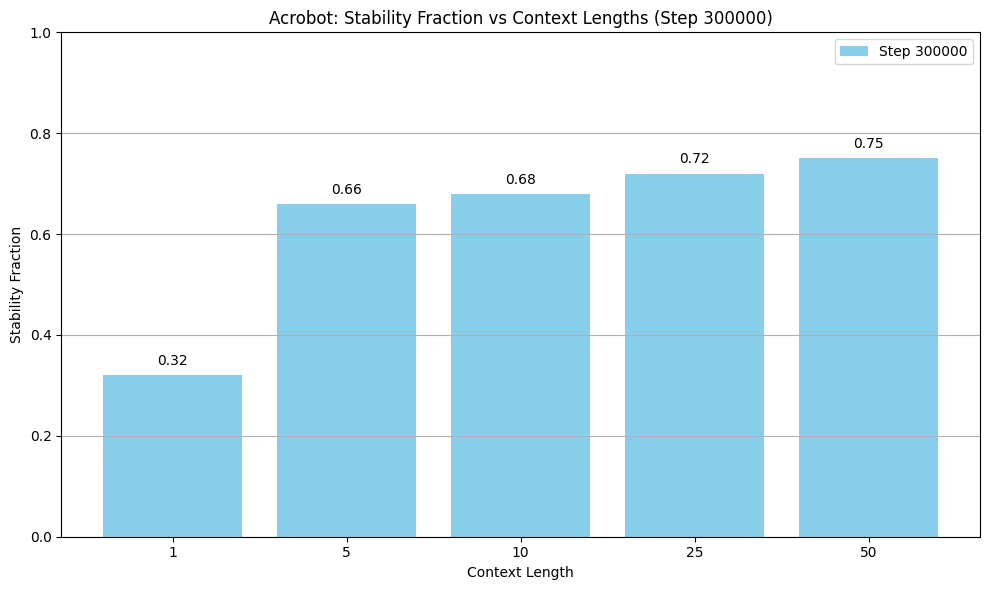

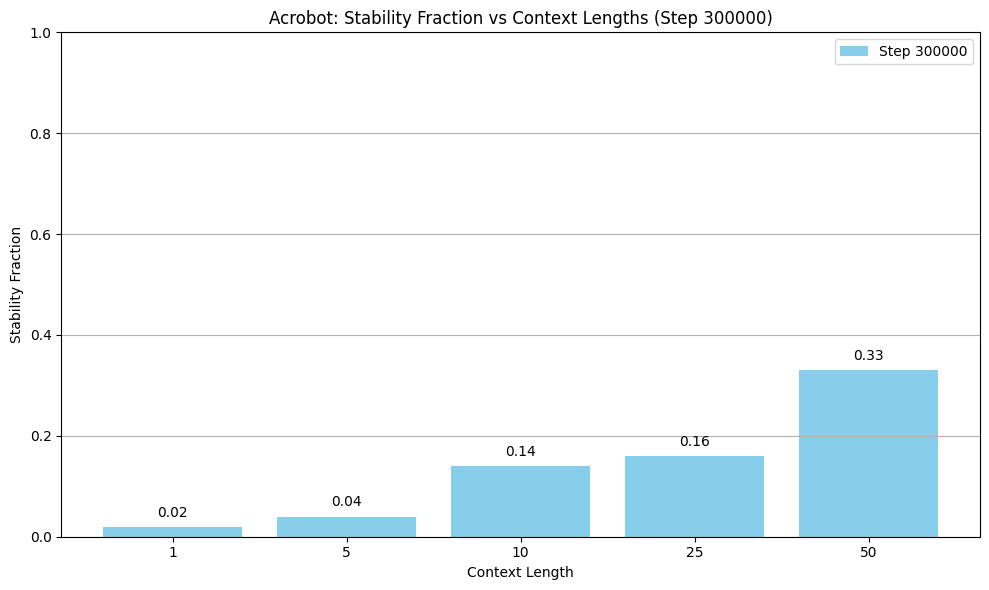

In [11]:
data2 = []
import matplotlib.pyplot as plt
import pandas as pd


for stp in steps_list2:
    for metric in metrics2:
        # print(f"Step: {stp}, Metric: {metric}")
        # for ctx in context_lengths:
        for ctx in contexts2:
            for mode in modes:
                if metric == 'stability_fraction':
                    # val = results2[metric][(stp, ctx)]
                    # print(f"  Context: {ctx}, Stability Fraction: {val}")
                    data2.append({
                        'metric': metric,
                        'step': stp,
                        'context': ctx,
                        'mode': mode,
                        'value': results2[metric][(stp, ctx, mode)]
                    })
                else:
                    pass


# visualize results: fraction over context
# fig_ctx, ax_ctx = plt.subplots(figsize=(10, 6))
df2 = pd.DataFrame(data2)
df2 = df2.sort_values(by='context')

# debugging
# print(f"Data for plotting: {df2.head()}")

metric = 'stability_fraction'
metric_data = df2[df2['metric'] == metric]
# plot stability fraction vs context for each step
for stp in steps_list2:
    for mode in modes:
        # fig_ctx, ax_ctx = plt.subplots(figsize=(10, 6))   # line graph
        step_metric_data = metric_data[(metric_data['step'] == stp) & (metric_data['mode'] == mode)]
        # ax_ctx.plot(step_metric_data['context'], step_metric_data['value'], label=f'Step {stp}', marker='o')
        # ax_ctx.set_title(f'Acrobot: Stability Fraction vs Context Lengths (Step {stp})')
        # ax_ctx.set_xlabel('Context Length')
        # ax_ctx.set_ylabel('Stability Fraction')
        # ax_ctx.set_ylim(0, 1)
        # ax_ctx.set_xticks(contexts)
        # ax_ctx.set_xlim(1, max(contexts)+1)
        # ax_ctx.legend()
        # ax_ctx.grid(True)


        fig_ctx2, ax_ctx2 = plt.subplots(figsize=(10, 6))  # bar graph
        x_label_list = step_metric_data['context'].astype(str).tolist()  # Convert context values to strings for x-axis labels
        ax_ctx2.bar(x_label_list, step_metric_data['value'], label=f'Step {stp}', color='skyblue')
        ax_ctx2.set_title(f'Acrobot: Stability Fraction vs Context Lengths (Step {stp})')
        ax_ctx2.set_xlabel('Context Length')
        ax_ctx2.set_ylabel('Stability Fraction')
        ax_ctx2.set_ylim(0, 1)
        # ax_ctx2.set_xticks(contexts)
        # ax_ctx2.set_xlim(1, max(contexts)+1)
        ax_ctx2.legend()
        ax_ctx2.grid(True, axis='y')
        # add value labels on top of bars
        for i, v in enumerate(step_metric_data['value']):
            ax_ctx2.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

        


        plt.tight_layout()
        plt.show()

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- 1. SET PAPER-READY STYLING ---
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 20,
    'font.family': 'serif'
})

# --- 2. PREPARE DATA ---
data2 = []
metric = 'stability_fraction'

for stp in steps_list2:
    for ctx in contexts2:
        for mode in modes:
            val = results2[metric].get((stp, ctx, mode), 0.0)
            data2.append({
                'step': stp,
                'context': ctx,
                'mode': mode,
                'value': val
            })
        # Add Nominal Baseline (Hardcoded 0 as per your finding)
        data2.append({
            'step': stp,
            'context': ctx,
            'mode': 'nominal',
            'value': 0.0
        })

df_plot = pd.DataFrame(data2)

# --- 2. DATA PROCESSING ---
# Filter out the 'nominal' from the main grouped bars 
# and handle it as a separate scalar.
metric = 'stability_fraction'

for stp in steps_list2:
    fig, ax = plt.subplots(figsize=(11, 9.5))
    
    # Contexts for the X-axis
    sorted_contexts = sorted(contexts2)
    x = np.arange(len(sorted_contexts))
    width = 0.35 
    
    # 3. PLOT TRANSFORMER DATA (In-Distr and OOD)
    # Filter data for this specific step
    step_data = df_plot[df_plot['step'] == stp]
    
    # In-Distribution Bars
    in_dist_vals = [step_data[(step_data['context'] == c) & (step_data['mode'] == 'indistr')]['value'].values[0] for c in sorted_contexts]
    ax.bar(x - width/2, in_dist_vals, width, label='Transformer (In-Distr)', color='#4C72B0', edgecolor='black', alpha=0.9)
    
    # OOD Bars
    ood_vals = [step_data[(step_data['context'] == c) & (step_data['mode'] == 'ood')]['value'].values[0] for c in sorted_contexts]
    ax.bar(x + width/2, ood_vals, width, label='Transformer (OOD)', color='#DD8452', edgecolor='black', alpha=0.9)

    # 4. THE NOMINAL BASELINE (Reviewer 2 Defense)
    # Since it's 0.0, a horizontal line is hard to see. 
    # We plot it as a dashed line slightly above the axis for visibility, or at 0.
    # Note: These values come from evaluate_acrobot_nomctrlr.py results.
    nominal_val_indistr = 0.26
    ax.axhline(y=nominal_val_indistr, color='#4C72B0', linestyle='--', linewidth=2, label=f'Nominal Baseline (In-Distr): {nominal_val_indistr:.2f}')

    nominal_val = 0.01 
    ax.axhline(y=nominal_val, color='red', linestyle='--', linewidth=2, label=f'Nominal Baseline (OOD): {nominal_val:.2f}')
    
    # Add a text annotation near the axis to make the 0% "pop"
    # ax.text(len(sorted_contexts)-3, nominal_val + 0.02, 'Nominal Baseline = 0.0', color='red', 
    #         fontweight='bold', ha='right', va='bottom', fontsize=12)

    # ax.text(len(sorted_contexts)-3, nominal_val_indistr + 0.02, f'Nominal Baseline (In-Distr) = {nominal_val_indistr:.2f}', color='#4C72B0',
    #         fontweight='bold', ha='right', va='bottom', fontsize=12)

    # 5. FINAL POLISHING
    ax.set_ylabel('Stability Fraction')
    ax.set_xlabel(r'Context Length ($k$)')
    ax.set_title(f'Acrobot Universal Control: Zero-Input ICL Generalization', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_ylim(-0.05, 1.1) # Start slightly below 0 so the baseline line is visible
    
    # Put legend outside or in a clear spot
    ax.legend(loc='upper left', frameon=True, shadow=False, framealpha=0.6)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Value labels for Transformer bars
    for i, v in enumerate(in_dist_vals):
        ax.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold')
    for i, v in enumerate(ood_vals):
        ax.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold')

    plt.tight_layout()
    # plt.show()

    save_folder = "paper_plots_acrobot"
    os.makedirs(save_folder, exist_ok=True)
    file_name = f'stability_fraction_vs_context_step{stp}.pdf'
    plt.savefig(os.path.join(save_folder, file_name), format='pdf', bbox_inches='tight')
    plt.close()

In [ ]:
# # data2 = []
# # import matplotlib.pyplot as plt
# # import pandas as pd


# # for stp in steps_list2:
# #     for metric in metrics2:
# #         print(f"Step: {stp}, Metric: {metric}")
# #         for ctx in context_lengths:
# #             if metric == 'stability_fraction' and ctx != 50:
# #                 # val = results2[metric][(stp, ctx)]
# #                 # print(f"  Context: {ctx}, Stability Fraction: {val}")
# #                 data2.append({
# #                     'metric': metric,
# #                     'step': stp,
# #                     'context': ctx,
# #                     'value': results2[metric][(stp, ctx)]
# #                 })
# #             else:
# #                 pass


# # # visualize results: fraction over context
# # fig_ctx, ax_ctx = plt.subplots(figsize=(10, 6))
# # df2 = pd.DataFrame(data2)
# # df2 = df2.sort_values(by='context')

# # metric = 'stability_fraction'
# # metric_data = df2[df2['metric'] == metric]
# # ax_ctx.plot(metric_data['context'], metric_data['value'], label='Stability Fraction', marker='o')
# # ax_ctx.set_title(f'Acrobot: Stability Fraction vs Context Lengths (Step {step})')
# # ax_ctx.set_xlabel('Context Length')
# # ax_ctx.set_ylabel('Stability Fraction')
# # ax_ctx.set_ylim(0, 1)
# # ax_ctx.legend()
# # ax_ctx.grid(True)
# # plt.tight_layout()
# # plt.show()

# # create subfolder and save plot
# output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
# os.makedirs(output_dir, exist_ok=True)
# subfolder = f"contexts_vs_stability_fraction_100systems_all"
# os.makedirs(os.path.join(output_dir, subfolder), exist_ok=True)
# # fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systems_mode{mode}.png'))
# fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systemsall.pdf'), format='pdf', bbox_inches='tight')